In [3]:
# UCB ACQUISITION FUNCTION
def upper_confidence_bound(mu, sigma, kappa=2.0):
    """
    kappa = 1.96  -> 95% confidence (Balanced)
    kappa = 2.576 -> 99% confidence (More Exploration)
    """
    return mu + (kappa * sigma)
    
def expected_improvement(mu, sigma, y_best, xi=0.01):
    with np.errstate(divide='warn'):
        improvement = mu - y_best - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

In [4]:
import numpy as np
import pandas as pd

# Detect likely contamination sources in a two-dimensional area, such as a radiation field, 
# where only proximity yields a non-zero reading.
# The system uses Bayesian optimisation to tune detection parameters and reliably identify both strong and weak sources.

# Set random seed for reproducibility
np.random.seed(42)

X = np.load('initial_inputs.npy')
y = np.load('initial_outputs.npy')

# X_initial and y_initial should already exist from baseline points
X_initial = X.copy()
y_initial = y.copy()

X_weekly_list = []
y_weekly_list = []

# --- WEEKLY UPDATE SECTION ---
new_queries = [
    [0.828282, 0.777777], # Week 1
    [0.636363, 0.676767], # Week 2
    [0.717171, 0.797979]  # Week 3
]
new_results = [
    -1.6268381341133806e-44, # Week 1
    -0.014642396013764629, # Week 2
    -6.327113026161975e-26 # Week 3
]

# Create the "Weekly Only" arrays for your Distance and Sensitivity plots
X_weekly = np.array(new_queries)
y_weekly = np.array(new_results)

# Reference for convenience
X_lastweek = X_weekly[-1]
y_lastweek = y_weekly[-1]

# Automatically update your main dataset
X = np.vstack([X_initial, new_queries])
y = np.append(y_initial, new_results)

print('-- inputs X ---')
print(X)
print("X shape=",X.shape)

print('-- outputs y ---')
print(y)
print("y shape=",y.shape)


df = pd.DataFrame(X, columns=["x1","x2"])
df['y'] = np.abs(y)
# df['y'] = y
df = df.sort_values(by='y', ascending=False)
df

# Week1 result now in 2nd from bottom
# week1_X = [0.828282, 0.777777]
# week1_y = 1.6268381341133806e-44
# 10	0.828282	0.777777	1.626838e-44 --week1
# 11	0.636363	0.676767	-1.464240e-02 --week2 --> 1st
# 12	0.717171	0.797979	-6.327113e-26 --week3 --> 4rd

-- inputs X ---
[[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.828282   0.777777  ]
 [0.636363   0.676767  ]
 [0.717171   0.797979  ]]
X shape= (13, 2)
-- outputs y ---
[ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048 -1.62683813e-044 -1.46423960e-002
 -6.32711303e-026]
y shape= (13,)


,x1,x2,y
11,0.636363,0.676767,1.464240e-02
4,0.650114,0.681526,3.606063e-03
2,0.731024,0.733000,7.710875e-16
12,0.717171,0.797979,6.327113e-26
7,0.683418,0.861057,2.535001e-40
10,0.828282,0.777777,1.626838e-44
1,0.574329,0.879898,1.033078e-46
9,0.883890,0.582254,6.229856e-48
5,0.410437,0.147554,2.159249e-54
0,0.319404,0.762959,1.322677e-79


In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Clip the extreme lows to a 'floor' before logging
# This prevents the 'cliffs' in your data
# y_clipped = np.clip(np.abs(y), a_min=1e-50, a_max=None) 
# y_log = np.log10(y_clipped) # log10 is often easier to interpret than ln

y_log = np.log10(np.abs(y))
y_scaled = scaler.fit_transform(y_log.reshape(-1, 1)).flatten()

y_initial_log = np.log10(np.abs(y_initial))
y_initial_scaled = scaler.fit_transform(y_initial.reshape(-1, 1)).flatten()

df_scaled = pd.DataFrame(X, columns=["x1","x2"])
df_scaled['y'] = y_scaled
df_scaled = df_scaled.sort_values(by='y', ascending=False)
df_scaled

,x1,x2,y
11,0.636363,0.676767,1.395092
4,0.650114,0.681526,1.377417
2,0.731024,0.733000,1.009445
12,0.717171,0.797979,0.716521
7,0.683418,0.861057,0.298383
10,0.828282,0.777777,0.176616
1,0.574329,0.879898,0.112803
9,0.883890,0.582254,0.077381
5,0.410437,0.147554,-0.110242
0,0.319404,0.762959,-0.842498


In [6]:
sorted_idx = np.argsort(y_scaled)[::-1]

best_idx      = sorted_idx[0]
second_idx    = sorted_idx[1]
third_idx     = sorted_idx[2]

x_best  = X[best_idx]
x_second_best = X[second_idx]
x_third_best  = X[third_idx]

y_best        = y[best_idx]
y_second_best = y[second_idx]
y_third_best  = y[third_idx]

y_best_scaled = np.max(y_scaled)

print(sorted_idx)

print(f"Current Best x_idx: {best_idx}")
print(f"Current Best x: {x_best}")
print(f"Current Best y: {y_best}")
print(f"Current Best y_scaled: {y_best_scaled}")

print(f"Current 2nd Best x: {x_second_best}, y:{y_second_best}")
print(f"Current 3nd Best x: {x_third_best}, y:{y_third_best}")

# print('-- outputs y ---')
# print(y_log)
# print("y shape=",y.shape)

[11  4  2 12  7 10  1  9  5  0  8  6  3]
Current Best x_idx: 11
Current Best x: [0.636363 0.676767]
Current Best y: -0.014642396013764629
Current Best y_scaled: 1.3950921335697337
Current 2nd Best x: [0.65011406 0.68152635], y:-0.0036060626443634764
Current 3nd Best x: [0.73102363 0.73299988], y:7.710875114502849e-16


In [7]:
import numpy as np
import warnings
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, ConstantKernel, WhiteKernel
from sklearn.exceptions import ConvergenceWarning
import matplotlib.pyplot as plt
from scipy.stats import norm

warnings.filterwarnings('ignore', category=ConvergenceWarning)
# week4 
kernel = (
    ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=0.05, length_scale_bounds=(1e-3, 1.0), nu=1.5) +
    WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-10, 1e-1))
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=0.0,
    normalize_y=False,
    n_restarts_optimizer=20,
    random_state=42
)
gp.fit(X, y_scaled)

print(f"Optimized Kernel: {gp.kernel_}")
print(f"Training R^2 Score: {gp.score(X, y_log)}")
print(f"Total variance accounted for as noise: {gp.alpha}")


Optimized Kernel: 1.31**2 * Matern(length_scale=0.334, nu=1.5) + WhiteKernel(noise_level=1e-10)
Training R^2 Score: -2.04052794685721
Total variance accounted for as noise: 0.0


In [8]:
# Create grid of potential X values
res=100
x_coord = np.linspace(0, 1, 100)
X1, X2 = np.meshgrid(x_coord, x_coord)
X_grid = np.vstack([X1.ravel(), X2.ravel()]).T

# Get predictions
mu, sigma = gp.predict(X_grid, return_std=True)

sigma = sigma.reshape(-1, 1)
mu = mu.reshape(-1, 1)


In [9]:
kappa=2.0
ucb_values = upper_confidence_bound(mu, sigma, kappa)

ucb_next_idx = np.argmax(ucb_values)
ucb_next_query = X_grid[ucb_next_idx]

print(f"--- Optimization Results ---")
print(f"UCB Score with kappa: {kappa}")
print(f"Current Best y: {y_best}, y_best_scaled: {y_best_scaled}")
print(f"Suggested next: {ucb_next_query}")

--- Optimization Results ---
UCB Score with kappa: 2.0
Current Best y: -0.014642396013764629, y_best_scaled: 1.3950921335697337
Suggested next: [0.55555556 0.51515152]


In [10]:
xi=0.01
ei_values = expected_improvement(mu, sigma, y_best_scaled, xi)

# Get the next best point
ei_next_idx = np.argmax(ei_values)
ei_next_query = X_grid[ei_next_idx]

print(f"--- Optimization Results ---")
print(f"expected_improvement with xi: {xi}")
print(f"Current Best y: {y_best}, y_best_scaled: {y_best_scaled}")
print(f"Suggested next: {ei_next_query}")

--- Optimization Results ---
expected_improvement with xi: 0.01
Current Best y: -0.014642396013764629, y_best_scaled: 1.3950921335697337
Suggested next: [0.61616162 0.58585859]


In [11]:
# import numpy as np
# import matplotlib.cm as cm
# import matplotlib.pyplot as plt
# from matplotlib.colors import Normalize

# # 1. Feature Sensitivity (Length Scales)
# # We plot 1/Length_Scale because a higher value = higher importance
# # lscales = gp.kernel_.k2.length_scale
# lscales=np.array([0.0931, 0.05])
# sensitivities = 1 / lscales
# names = ['X1', 'X2']

# # Create a colormap (e.g., 'viridis', 'plasma', or 'coolwarm') 
# # and normalize it based on the sensitivity values
# norm = Normalize(vmin=min(sensitivities), vmax=max(sensitivities))
# colors = cm.viridis(norm(sensitivities))

# # Create the bar plot using the 'colors' array
# bars = plt.bar(names, sensitivities, color=colors)

# # Create the bar plot and store the container in 'bars'
# # bars = plt.bar(names, sensitivities, color='teal')
# plt.ylabel('Relative Sensitivity (1/LengthScale)')
# plt.title('Radiation Field Map')

# # Annotate each bar with its value
# for bar in bars:
#     yval = bar.get_height()
#     # We place the text at (x_center, y_top)
#     # va='bottom' ensures the text sits just above the bar
#     text_location = bar.get_x() + bar.get_width()/2
#     plt.text(text_location, yval, f'{yval:.2f}', va='bottom', ha='center', fontsize=10)

# # Adjust y-limit slightly to make room for the labels at the top
# plt.ylim(0, max(sensitivities) * 1.15)

# plt.show()

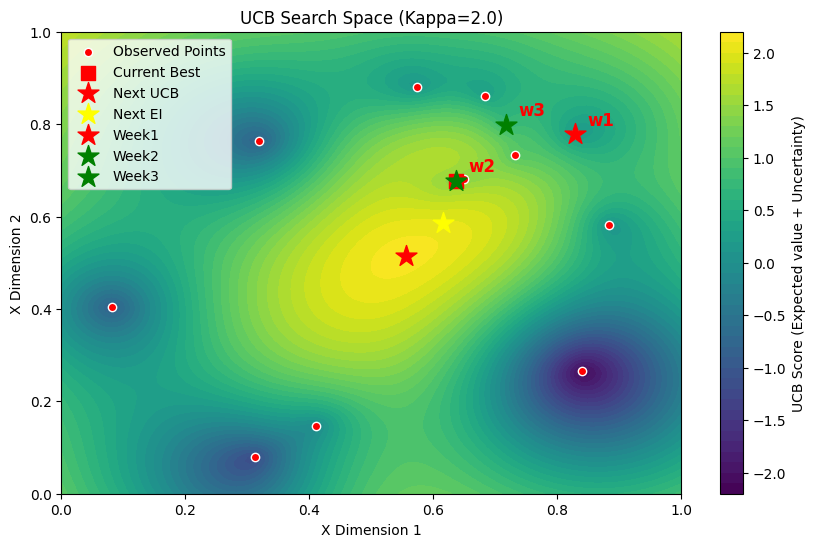

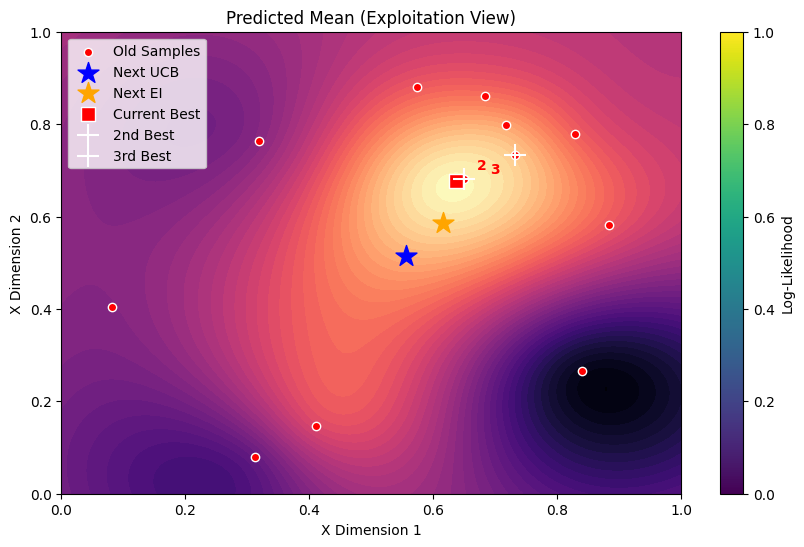

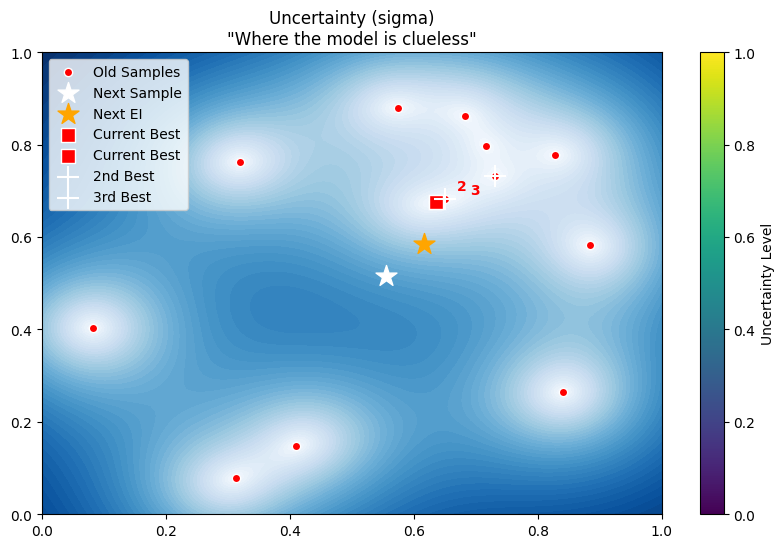

In [12]:
# UCB VISUALIZATION
ucb_map = ucb_values.reshape(res, res)
week1_query= X_weekly[0]
week2_query= X_weekly[1]
week3_query= X_weekly[2]

plt.figure(figsize=(10, 6))
plt.contourf(X1, X2, ucb_map, levels=50, cmap='viridis')
plt.colorbar(label='UCB Score (Expected value + Uncertainty)')
plt.scatter(X[:, 0], X[:, 1], c='red', edgecolors='white', label='Observed Points')

plt.scatter(X[best_idx, 0], X[best_idx, 1], c='red', marker='s', s=100, label='Current Best')
plt.scatter(ucb_next_query[0], ucb_next_query[1], c='red', marker='*', s=250, label='Next UCB')
plt.scatter(ei_next_query[0], ei_next_query[1], c='yellow', marker='*', s=250, label='Next EI')

plt.scatter(week1_query[0], week1_query[1], c='red', marker='*', s=250, label='Week1')
plt.text(week1_query[0] + 0.02, week1_query[1] + 0.02, 'w1', fontsize=12, fontweight='bold', color='red')
plt.scatter(week2_query[0], week2_query[1], c='green', marker='*', s=250, label='Week2')
plt.text(week2_query[0] + 0.02, week2_query[1] + 0.02, 'w2', fontsize=12, fontweight='bold', color='red')
plt.scatter(week3_query[0], week3_query[1], c='green', marker='*', s=250, label='Week3')
plt.text(week3_query[0] + 0.02, week3_query[1] + 0.02, 'w3', fontsize=12, fontweight='bold', color='red')

# plt.scatter(x_second_best[0], x_second_best[1], c='white', marker='+', s=250, label='2nd Best')
# plt.text(x_second_best[0] + 0.02, x_second_best[1] + 0.02, '2', fontsize=10, fontweight='bold', color='red')
# plt.scatter(x_third_best[0], x_third_best[1], c='white', marker='+', s=250, label='3rd Best')
# plt.text(x_third_best[0] - 0.04, x_third_best[1] - 0.04, '3', fontsize=10, fontweight='bold', color='red')


plt.title(f"UCB Search Space (Kappa={kappa})")
plt.xlabel("X Dimension 1")
plt.ylabel("X Dimension 2")
plt.legend()
plt.show()

mu_map = mu.reshape(res, res)
plt.figure(figsize=(10, 6))
plt.contourf(X1, X2, mu_map, levels=50, cmap='magma')
plt.scatter(X[:, 0], X[:, 1], c='red', edgecolors='white', label='Old Samples')

plt.scatter(ucb_next_query[0], ucb_next_query[1], c='blue', marker='*', s=250, label='Next UCB')
plt.scatter(ei_next_query[0], ei_next_query[1], c='orange', marker='*', s=250, label='Next EI')

plt.scatter(X[best_idx, 0], X[best_idx, 1], c='red', edgecolors='white', marker='s', s=100, label='Current Best')
plt.scatter(x_second_best[0], x_second_best[1], c='white', marker='+', s=250, label='2nd Best')
plt.text(x_second_best[0] + 0.02, x_second_best[1] + 0.02, '2', fontsize=10, fontweight='bold', color='red')
plt.scatter(x_third_best[0], x_third_best[1], c='white', marker='+', s=250, label='3rd Best')
plt.text(x_third_best[0] - 0.04, x_third_best[1] - 0.04, '3', fontsize=10, fontweight='bold', color='red')

plt.title('Predicted Mean (Exploitation View)')
plt.colorbar(label='Log-Likelihood')
plt.xlabel("X Dimension 1")
plt.ylabel("X Dimension 2")
plt.legend()
plt.show()

sigma_map = sigma.reshape(res, res)
plt.figure(figsize=(10, 6))
plt.contourf(X1, X2, sigma_map, levels=50, cmap='Blues')
plt.scatter(X[:, 0], X[:, 1], c='red', edgecolors='white', label='Old Samples')
plt.scatter(ucb_next_query[0], ucb_next_query[1], c='white', marker='*', s=250, label='Next Sample')
plt.scatter(ei_next_query[0], ei_next_query[1], c='orange', marker='*', s=250, label='Next EI')

plt.scatter(X[best_idx, 0], X[best_idx, 1], c='red', edgecolors='white', marker='s', s=100, label='Current Best')
plt.scatter(X[best_idx, 0], X[best_idx, 1], c='red', edgecolors='white', marker='s', s=100, label='Current Best')
plt.scatter(x_second_best[0], x_second_best[1], c='white', marker='+', s=250, label='2nd Best')
plt.text(x_second_best[0] + 0.02, x_second_best[1] + 0.02, '2', fontsize=10, fontweight='bold', color='red')
plt.scatter(x_third_best[0], x_third_best[1], c='white', marker='+', s=250, label='3rd Best')
plt.text(x_third_best[0] - 0.04, x_third_best[1] - 0.04, '3', fontsize=10, fontweight='bold', color='red')

# plt.scatter(week1_query[0], week1_query[1], c='red', marker='*', s=250, label='Last Query')
# plt.text(week1_query[0] + 0.02, week1_query[1] + 0.02, 'w1', fontsize=12, fontweight='bold', color='red')
# plt.scatter(week2_query[0], week2_query[1], c='green', marker='*', s=250, label='Week2')
# plt.text(week2_query[0] + 0.02, week2_query[1] + 0.02, 'w2', fontsize=12, fontweight='bold', color='red')


plt.title('Uncertainty (sigma)\n"Where the model is clueless"')
plt.colorbar(label='Uncertainty Level')
plt.legend()
plt.show()

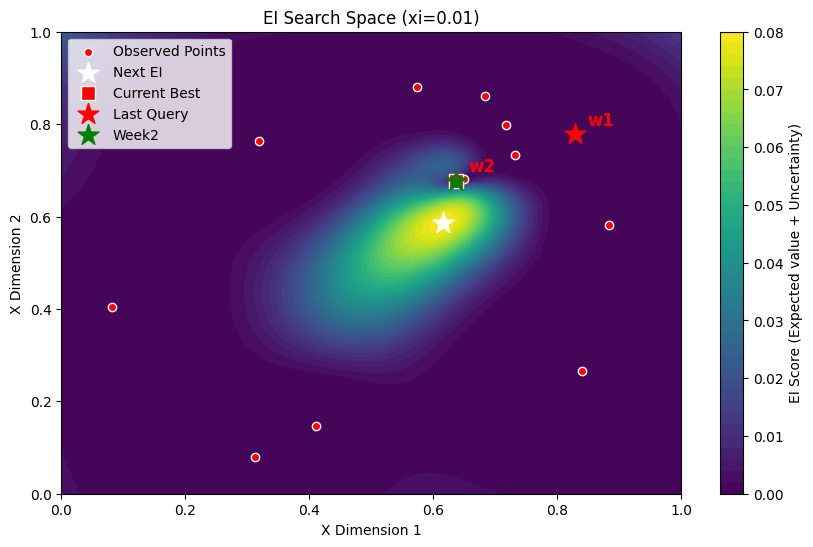

In [13]:
# EI VISUALIZATION
ei_map = ei_values.reshape(res, res)
plt.figure(figsize=(10, 6))
plt.contourf(X1, X2, ei_map, levels=50, cmap='viridis')
plt.colorbar(label='EI Score (Expected value + Uncertainty)')
plt.scatter(X[:, 0], X[:, 1], c='red', edgecolors='white', label='Observed Points')
plt.scatter(ei_next_query[0], ei_next_query[1], c='white', marker='*', s=250, label='Next EI')
plt.scatter(X[best_idx, 0], X[best_idx, 1], c='red', edgecolors='white', marker='s', s=100, label='Current Best')


plt.scatter(week1_query[0], week1_query[1], c='red', marker='*', s=250, label='Last Query')
plt.text(week1_query[0] + 0.02, week1_query[1] + 0.02, 'w1', fontsize=12, fontweight='bold', color='red')
plt.scatter(week2_query[0], week2_query[1], c='green', marker='*', s=250, label='Week2')
plt.text(week2_query[0] + 0.02, week2_query[1] + 0.02, 'w2', fontsize=12, fontweight='bold', color='red')

plt.title(f"EI Search Space (xi={xi})")
plt.xlabel("X Dimension 1")
plt.ylabel("X Dimension 2")
plt.legend()
plt.show()

In [14]:
#    x1           x2          y     
# 11 0.636363	0.676767	1.395092  <-- best so far 
# 4	0.650114	0.681526	1.377417
# 2	0.731024	0.733000	1.009445

# --- Optimization Results ---
# expected_improvement with xi: 0.01
# Current Best y: -0.014642396013764629, y_best_scaled: 1.3950921335697337
# Suggested next: [0.61616162 0.58585859]
    
# --- Optimization Results ---
# UCB Score with kappa: 2.0
# Current Best y: -0.014642396013764629, y_best_scaled: 1.3950921335697337
# Suggested next: [0.55555556 0.51515152]

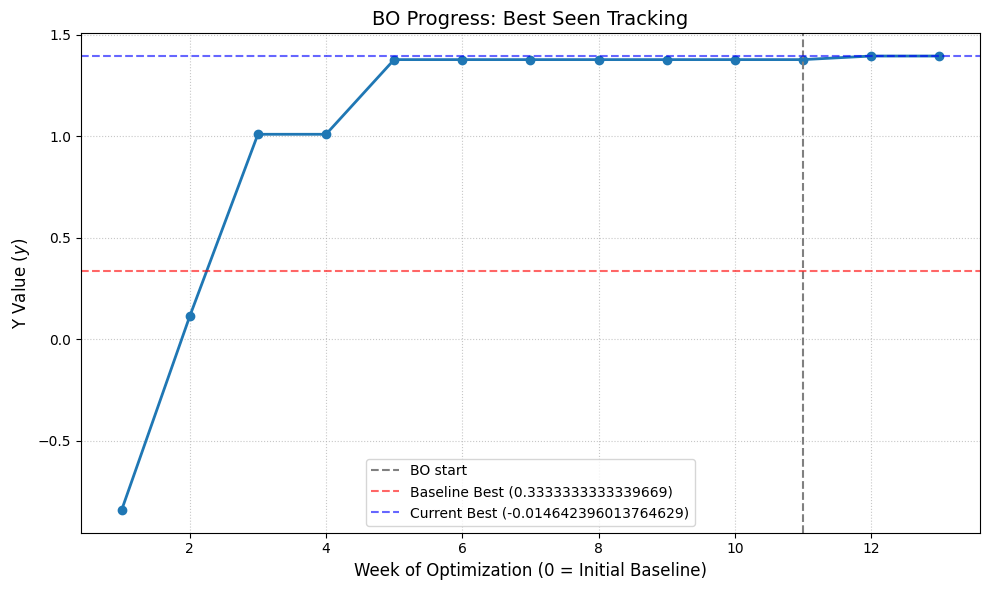

In [15]:
# Convergence Report
y_observed = y_scaled
baseline_best = np.max(y_initial_scaled)

weekly = np.arange(1, len(y_observed) + 1)
best_seen_trace = np.maximum.accumulate(y_observed)

bo_start_idx = 10  # zero-based index of first BO point

plt.figure(figsize=(10,6))
plt.plot(weekly, best_seen_trace, marker='o', linewidth=2)

# Vertical line separating phases
plt.axvline(x=bo_start_idx + 1, color='gray', linestyle='--', label='BO start')

# Plot the baseline best as a horizontal reference
plt.axhline(y=baseline_best, color='red', linestyle='--', alpha=0.6, label=f'Baseline Best ({baseline_best})')
plt.axhline(y=y_best_scaled, color='blue', linestyle='--', alpha=0.6, label=f'Current Best ({y_best})')

# Plot the individual weekly results
# plt.scatter(y_weekly_log[0:], y, color='black', zorder=3, label='Weekly Query Result ($y_t$)')

plt.title('BO Progress: Best Seen Tracking', fontsize=14)
plt.xlabel('Week of Optimization (0 = Initial Baseline)', fontsize=12)
plt.ylabel('Y Value ($y$)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()

# Highlight improvement
improvement = best_seen_trace[-1] - baseline_best
# if improvement > 0:
#     plt.annotate(f'Total Improvement: +{improvement:.2f}', 
#                  xy=(weekly[-1], best_seen_trace[-1]), 
#                  xytext=(weekly[-1]+2, best_seen_trace[-1] + 2),
#                  arrowprops=dict(facecolor='green', shrink=0.05))

plt.tight_layout()
plt.show()



In [16]:
# Metrics History
from scipy.spatial.distance import euclidean

ucb_next_query_dist = euclidean(ucb_next_query, x_best)
ei_next_query_dist = euclidean(ei_next_query, x_best)

print(f"Distance from Best X, ucb_next_query_dist:{ucb_next_query_dist}")
print(f"Distance from Best X, ei_next_query_dist:{ei_next_query_dist}")

# Calculate prediction Error
x_next = ucb_next_query

y_pred, sigma = gp.predict(x_next.reshape(1, -1), return_std=True)
confidence_value = sigma[0]

print(f"======== NextQuery==========") 
print(f"Query:{x_next}")
print(f"Model Confidence (σ): {confidence_value:.4f}")
print(f"Model Predicted: {y_pred[0]:.2f}")

## fill in weekly
# y_actual = -1.6268381341133806e-44
# prediction_error = np.abs(y_pred[0] - y_actual)
# print(f"Actual Result:  {y_actual:.2f}")
# print(f"Prediction Error: {prediction_error:.2f}")
print(f"Distance:{euclidean(x_next, x_best)}")

print("==================") 
print("Weekly Queries:") 
for i, (query, result) in enumerate(zip(new_queries, new_results), start=1):
    print(f"Week: {i} | Query: {query} | Result: {result:.8e}")

print("==================") 
print("Next Week Query: UCB")
print(ucb_next_query)

# new_queries = [
#     [0.828282, 0.777777], # Week 1
#     [0.636363, 0.676767]  # Week 2
# ]
# new_results = [
#     -1.6268381341133806e-44, # Week 1
#     -0.014642396013764629 # Week 2
# ]

Distance from Best X, ucb_next_query_dist:0.18069147190847934
Distance from Best X, ei_next_query_dist:0.09312591299253167
======== NextQuery==========
Query:[0.55555556 0.51515152]
Model Confidence (σ): 0.6720
Model Predicted: 0.79
Distance:0.18069147190847934
Weekly Queries:
Week: 1 | Query: [0.828282, 0.777777] | Result: -1.62683813e-44
Week: 2 | Query: [0.636363, 0.676767] | Result: -1.46423960e-02
Week: 3 | Query: [0.717171, 0.797979] | Result: -6.32711303e-26
Next Week Query: UCB
[0.55555556 0.51515152]
